### **Analyzing Leg Injuries in the NFL**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import PIL
from PIL import Image
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Augustin: /content/drive/MyDrive/Project 2/
# Connor: /content/drive/MyDrive/DS 201: Research Design/Project 2/
#Vinny:
# file_path = '/content/drive/MyDrive/Project 2/' # @param {type:"string"}
file_path = '/content/drive/MyDrive/Project 2/' # @param {type:"string"}
#file_path = '/content/drive/MyDrive/DS 201: Research Design/Project 2/' # @param {type:"string"}



In [ ]:
injury_df = pd.read_csv(file_path+'InjuryRecord.csv')

In [ ]:
player_list_df = pd.read_csv(file_path+'PlayList.csv')

In [ ]:
player_track_df = pd.read_csv(file_path+'PlayerTrackData.csv')
#player_track_df = pd.read_pickle(file_path+'player_track_df.pkl')

In [ ]:
injury_df[injury_df["BodyPart"] == "Heel"]

,PlayerKey,GameID,PlayKey,BodyPart,Surface,DM_M1,DM_M7,DM_M28,DM_M42
95,46134,46134-18,NaN,Heel,Natural,1,1,0,0


In [ ]:
def categorize_duration(row):
  if row['DM_M42'] == 1:
    return ">= 42 days"
  elif row['DM_M28'] == 1:
    return "28-41 days"
  elif row['DM_M7'] == 1:
    return "7-27 days"
  elif row['DM_M1'] == 1:
    return "1-6 days"
  else:
    return "Unknown"  # Handle cases where none of the conditions are met

# Apply the function to create the new column
injury_df['InjuryDuration'] = injury_df.apply(categorize_duration, axis=1)

In [ ]:
unique_players = player_list_df.PlayerKey.nunique()
unique_games = player_list_df.GameID.nunique()
unique_plays = player_list_df.PlayKey.nunique()

print('There are {} players in the dataset.'.format(unique_players))
print('There are {} games in the dataset.'.format(unique_games))
print('There are {} plays in the dataset.'.format(unique_plays))

There are 250 players in the dataset.
There are 5712 games in the dataset.
There are 267005 plays in the dataset.


### **Exploring the Injury DF**

In [ ]:
injury_df.head()

,PlayerKey,GameID,PlayKey,BodyPart,Surface,DM_M1,DM_M7,DM_M28,DM_M42,InjuryDuration
0,39873,39873-4,39873-4-32,Knee,Synthetic,1,1,1,1,>= 42 days
1,46074,46074-7,46074-7-26,Knee,Natural,1,1,0,0,7-27 days
2,36557,36557-1,36557-1-70,Ankle,Synthetic,1,1,1,1,>= 42 days
3,46646,46646-3,46646-3-30,Ankle,Natural,1,0,0,0,1-6 days
4,43532,43532-5,43532-5-69,Ankle,Synthetic,1,1,1,1,>= 42 days


In [ ]:
injury_df['BodyPart'].unique()

array(['Knee', 'Ankle', 'Foot', 'Toes', 'Heel'], dtype=object)

In [ ]:
injury_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PlayerKey       105 non-null    int64 
 1   GameID          105 non-null    object
 2   PlayKey         77 non-null     object
 3   BodyPart        105 non-null    object
 4   Surface         105 non-null    object
 5   DM_M1           105 non-null    int64 
 6   DM_M7           105 non-null    int64 
 7   DM_M28          105 non-null    int64 
 8   DM_M42          105 non-null    int64 
 9   InjuryDuration  105 non-null    object
dtypes: int64(5), object(5)
memory usage: 8.3+ KB


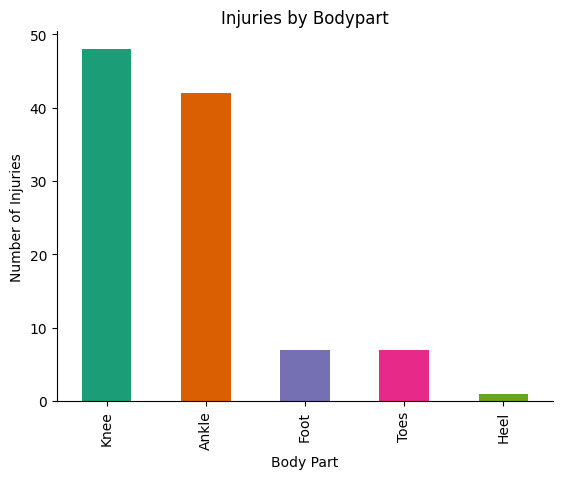

In [ ]:
# @title Injuries by Body Part
injury_df.groupby('BodyPart').size().sort_values(ascending=False).plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title('Injuries by Bodypart')
plt.xlabel('Body Part')
plt.ylabel('Number of Injuries')
plt.show()


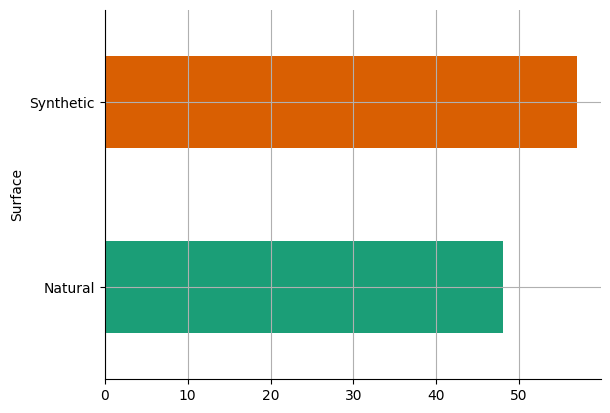

In [ ]:
# @title Injuries by Surface
injury_df.groupby('Surface').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.grid(True)

### **Cleaning the Playerlist DF**

In [ ]:
# Classifying Stadium Type by Outdoor, Indoor, and Unspecified. nan would still be considered unspecified
player_list_df['StadiumType'].unique()

stadium_type_clean_map = {'Outdoor':'Outdoor', 'Oudoor':'Outdoor', 'Outdoors':'Outdoor', 'Open':'Outdoor', 'Closed Dome':'Outdoor',
      'Retr. Roof Closed':'Outdoor', 'Outdor':'Outdoor', 'Outside':'Outdoor','Ourdoor':'Outdoor',
       'Domed, closed':'Outdoor', 'Domed':'Outdoor','Dome':'Outdoor',
       'Retr. Roof-Closed':'Outdoor', 'Outdoor Retr Roof-Open':'Outdoor', 'Retractable Roof':'Unspecified',
       'Indoors':'Indoor', 'Indoor':'Indoor',
        'Indoor, Roof Closed':'Indoor', 'Retr. Roof - Closed':'Indoor', 'Bowl':'Outdoor',
       'Outddors':'Outdoor', 'Retr. Roof-Open':'Outdoor', 'Dome, closed':'Outdoor', 'Indoor, Open Roof':'Indoor',
       'Domed, Open':'Outdoor', 'Domed, open':'Outdoor', 'Heinz Field':'Outdoor', 'Cloudy':'Outdoor',
       'Retr. Roof - Open':'Outdoor', np.nan:'Unspecified'}

player_list_df['StadiumTypeCleaned'] = player_list_df['StadiumType']
player_list_df['StadiumTypeCleaned'].replace(stadium_type_clean_map, inplace= True)

In [ ]:
# Mapping the weather values to common categories
weather_clean_map ={
    # Cloudy
      'Cloudy 50% change of rain':"Cloudy", 'Hazy':"Cloudy", 'Cloudy.':"Cloudy", 'Overcast':"Cloudy", 'Mostly Cloudy':"Cloudy",
      'Cloudy, fog started developing in 2nd quarter':"Cloudy", 'Partly Cloudy':"Cloudy",
      'Mostly cloudy':"Cloudy", 'Rain Chance 40%':"Cloudy",' Partly cloudy':"Cloudy", 'Party Cloudy':"Cloudy",
      'Rain likely, temps in low 40s':"Cloudy", 'Partly Clouidy':"Cloudy", 'Cloudy, 50% change of rain':"Cloudy",'Mostly Coudy':"Cloudy", '10% Chance of Rain':"Cloudy",
      'Cloudy, chance of rain':"Cloudy", '30% Chance of Rain':"Cloudy", 'Cloudy, light snow accumulating 1-3"':"Cloudy",
      'cloudy':"Cloudy", 'Coudy':"Cloudy", 'Cloudy with periods of rain, thunder possible. Winds shifting to WNW, 10-20 mph.':"Cloudy",
      'Cloudy fog started developing in 2nd quarter':"Cloudy", 'Cloudy light snow accumulating 1-3"':"Cloudy",
      'Cloudywith periods of rain, thunder possible. Winds shifting to WNW, 10-20 mph.':"Cloudy",
      'Cloudy 50% change of rain':"Cloudy", 'Cloudy and cold':"Cloudy",
      'Cloudy and Cool':"Cloudy", 'Partly cloudy':"Cloudy",
    # Clear
      'Clear, Windy':"Clear",' Clear to Cloudy':"Clear", 'Clear, highs to upper 80s':"Clear",
      'Clear and clear':"Clear",'Partly sunny':"Clear",
      'Clear, Windy':"Clear", 'Clear skies':"Clear", 'Sunny':"Clear", 'Partly Sunny':"Clear", 'Mostly Sunny':"Clear", 'Clear Skies':"Clear",
      'Sunny Skies':"Clear", 'Partly clear':"Clear", 'Fair':"Clear", 'Sunny, highs to upper 80s':"Clear", 'Sun & clouds':"Clear", 'Mostly sunny':"Clear",'Sunny, Windy':"Clear",
      'Mostly Sunny Skies':"Clear", 'Clear and Sunny':"Clear", 'Clear and sunny':"Clear",'Clear to Partly Cloudy':"Clear", 'Clear Skies':"Clear",
      'Clear and cold':"Clear", 'Clear and warm':"Clear", 'Clear and Cool':"Clear", 'Sunny and cold':"Clear", 'Sunny and warm':"Clear", 'Sunny and clear':"Clear",
    # Rainy
      'Rainy':"Rainy", 'Scattered Showers':"Rainy", 'Showers':"Rainy", 'Cloudy Rain':"Rainy", 'Light Rain':"Rainy", 'Rain shower':"Rainy",
      'Rain likely, temps in low 40s.':"Rainy", 'Cloudy, Rain':"Rainy","Rain":"Rainy","rain:Rainy"
    # Snow
      "Heavy lake effect snow":'Snow','Heavy lake effect snow.':'Snow','Heavy lake effect snow':'Snow',
    # Indoor
      'Controlled Climate':"Indoor", 'Indoors':"Indoor", 'N/A Indoor':"Indoor", 'N/A (Indoors)':"Indoor",
    # Unspecified
      'Heat Index 95':"Unspecified", 'Cold':"Unspecified", np.isnan:"Unspecified",
}
# Creating a Cleaned Weather column, and using our dictionary to map to the correct categories
player_list_df['WeatherCleaned'] = player_list_df['Weather']
player_list_df['WeatherCleaned'].replace(weather_clean_map, inplace= True)

# If the game was played indoors, then the exterior weather does not matter, so we will overrwrite with 'Indoor'
player_list_df.loc[player_list_df['StadiumTypeCleaned'] == 'Indoor', 'WeatherCleaned'] = 'Indoor'

player_list_df.loc[player_list_df['WeatherCleaned'] == "Indoor", 'StadiumTypeCleaned'] = 'Indoor'

In [ ]:
merged_df = injury_df.merge(player_list_df, on=['PlayKey', 'GameID','PlayerKey' ], how = 'left')

full_merged_df = injury_df.merge(player_list_df, on=['PlayKey', 'GameID','PlayerKey' ], how = 'outer')
full_merged_df['InjuryOccured'] = full_merged_df['BodyPart'].notna()
full_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267034 entries, 0 to 267033
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   PlayerKey           267034 non-null  int64  
 1   GameID              267034 non-null  object 
 2   PlayKey             267006 non-null  object 
 3   BodyPart            105 non-null     object 
 4   Surface             105 non-null     object 
 5   DM_M1               105 non-null     float64
 6   DM_M7               105 non-null     float64
 7   DM_M28              105 non-null     float64
 8   DM_M42              105 non-null     float64
 9   InjuryDuration      105 non-null     object 
 10  RosterPosition      267006 non-null  object 
 11  PlayerDay           267006 non-null  float64
 12  PlayerGame          267006 non-null  float64
 13  StadiumType         250096 non-null  object 
 14  FieldType           267006 non-null  object 
 15  Temperature         267006 non-nul

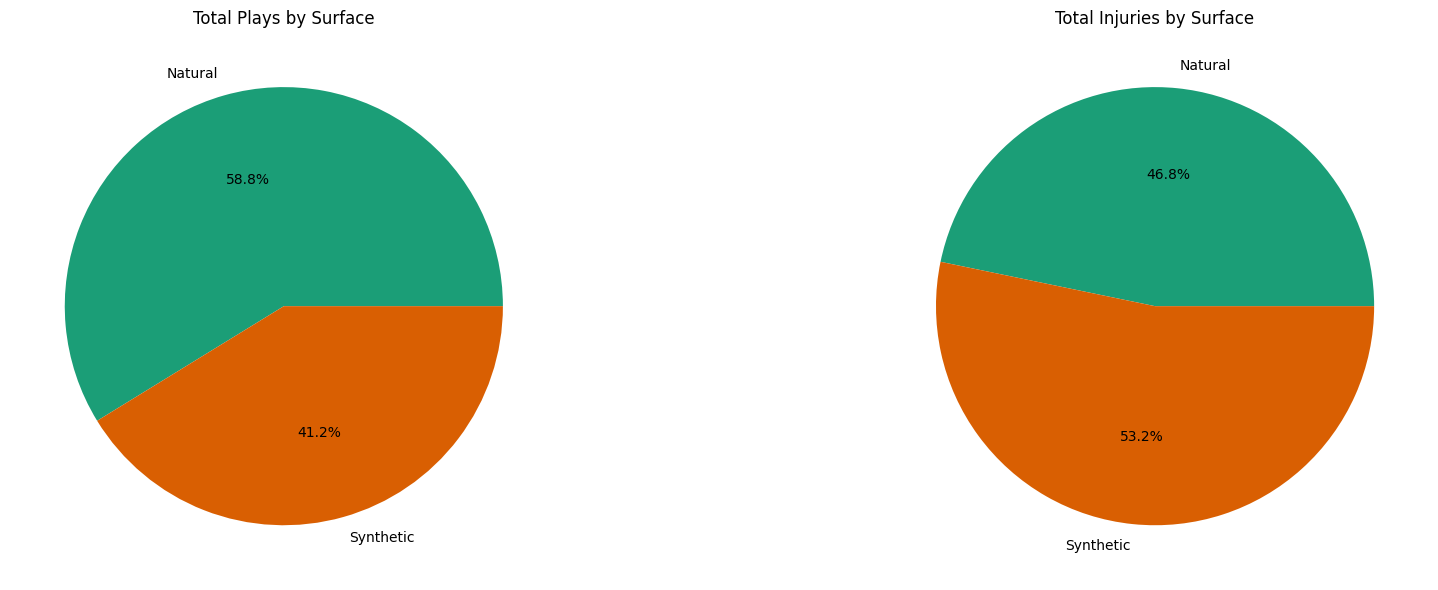

In [ ]:
# Set up the figure and axes for side-by-side pie charts
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

# Define colors
colors = sns.palettes.mpl_palette('Dark2')

# Total plays by surface
full_merged_df.groupby('FieldType').size().plot(kind='pie', autopct='%1.1f%%', colors=colors, ax=axs[0])
axs[0].set_ylabel('')  # Remove the y-label to make the chart look cleaner
axs[0].set_title('Total Plays by Surface')

# Total injuries by surface
full_merged_df[full_merged_df["InjuryOccured"]==True].groupby('FieldType').size().plot(kind='pie', autopct='%1.1f%%', colors=colors, ax=axs[1])
axs[1].set_ylabel('')  # Remove the y-label to make the chart look cleaner
axs[1].set_title('Total Injuries by Surface')

# Show the plot
plt.tight_layout()

plt.show()


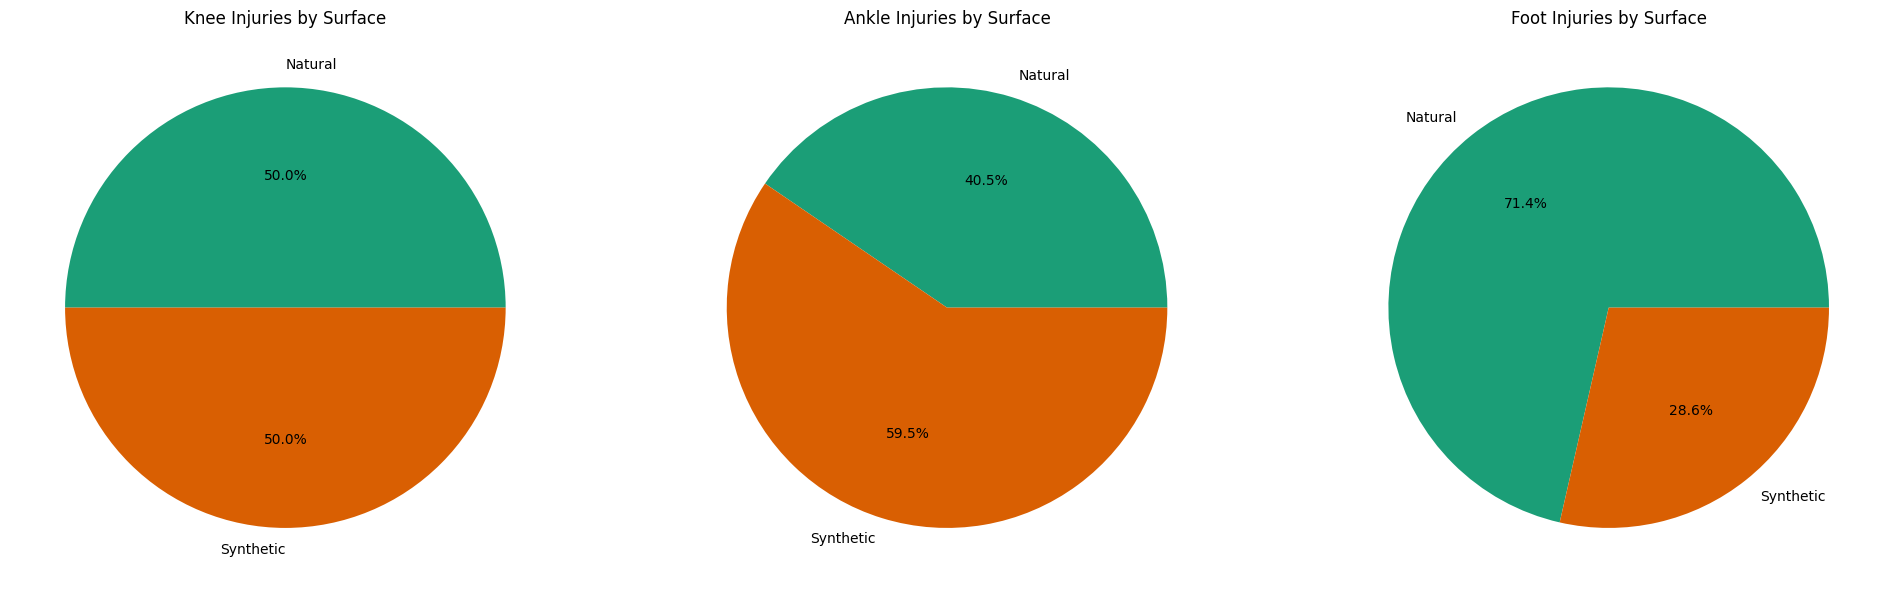

In [ ]:
# Set up the figure and axes for side-by-side pie charts
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Define colors
colors = sns.palettes.mpl_palette('Dark2')

# Injuries by surface filtered by body part
body_parts = ['Knee', 'Ankle', 'Foot']
i = 0
for body_part in body_parts:
    filtered_df = injury_df[injury_df['BodyPart'] == body_part]
    filtered_df.groupby('Surface').size().plot(kind='pie', autopct='%1.1f%%', colors=colors, ax=axs[i])
    axs[i].set_ylabel('')  # Remove the y-label to make the chart look cleaner
    axs[i].set_title(f'{body_part} Injuries by Surface')
    i+=1

# Show the plot
plt.tight_layout()

plt.show()

###**Exploring the Player List DF**

In [ ]:
player_list_df.head()

,PlayerKey,GameID,PlayKey,RosterPosition,PlayerDay,PlayerGame,StadiumType,FieldType,Temperature,Weather,PlayType,PlayerGamePlay,Position,PositionGroup,StadiumTypeCleaned,WeatherCleaned
0,26624,26624-1,26624-1-1,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Pass,1,QB,QB,Outdoor,Clear
1,26624,26624-1,26624-1-2,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Pass,2,QB,QB,Outdoor,Clear
2,26624,26624-1,26624-1-3,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Rush,3,QB,QB,Outdoor,Clear
3,26624,26624-1,26624-1-4,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Rush,4,QB,QB,Outdoor,Clear
4,26624,26624-1,26624-1-5,Quarterback,1,1,Outdoor,Synthetic,63,Clear and warm,Pass,5,QB,QB,Outdoor,Clear


In [ ]:
player_list_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267005 entries, 0 to 267004
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   PlayerKey           267005 non-null  int64 
 1   GameID              267005 non-null  object
 2   PlayKey             267005 non-null  object
 3   RosterPosition      267005 non-null  object
 4   PlayerDay           267005 non-null  int64 
 5   PlayerGame          267005 non-null  int64 
 6   StadiumType         250095 non-null  object
 7   FieldType           267005 non-null  object
 8   Temperature         267005 non-null  int64 
 9   Weather             248314 non-null  object
 10  PlayType            266638 non-null  object
 11  PlayerGamePlay      267005 non-null  int64 
 12  Position            267005 non-null  object
 13  PositionGroup       267005 non-null  object
 14  StadiumTypeCleaned  267005 non-null  object
 15  WeatherCleaned      255151 non-null  object
dtypes:

In [ ]:
# Group by PlayerKey and count occurrences
player_key_counts = injury_df.groupby('PlayerKey').size().reset_index(name='Count')

print(f"There are {player_key_counts.shape[0]} unique players in the injury dataframe")
player_key_counts

There are 100 unique players in the injury dataframe


,PlayerKey,Count
0,31070,1
1,31933,1
2,33337,2
3,33474,1
4,34347,1
...,...,...
95,47287,1
96,47307,2
97,47334,1
98,47382,1


In [ ]:
# Group by PlayerKey and count occurrences
player_key_counts = injury_df.groupby('PlayKey').size().reset_index(name='Count').sort_values(by='Count', ascending=False)

print(f"There are {player_key_counts.shape[0]} unique play keys in the injury dataframe")
player_key_counts

There are 76 unique play keys in the injury dataframe


,PlayKey,Count
72,47307-10-18,2
54,45950-8-18,1
53,45187-9-4,1
52,44900-7-10,1
51,44860-5-52,1
...,...,...
22,41145-2-60,1
21,41113-15-63,1
20,41094-1-55,1
19,40474-1-8,1


In [ ]:
# Group by PlayerKey and count occurrences
player_key_counts = player_list_df.groupby('PlayerKey').size().reset_index(name='Count')

print(f"There are {player_key_counts.shape[0]} unique players in the player dataframe")
player_key_counts

There are 250 unique players in the player dataframe


,PlayerKey,Count
0,26624,2207
1,27363,2011
2,30068,1946
3,30953,998
4,31070,278
...,...,...
245,47550,351
246,47784,423
247,47813,285
248,47820,184


In [ ]:
injury_df[injury_df['PlayKey'] == "47307-10-18"]

,PlayerKey,GameID,PlayKey,BodyPart,Surface,DM_M1,DM_M7,DM_M28,DM_M42,InjuryDuration
86,47307,47307-10,47307-10-18,Knee,Synthetic,1,1,0,0,7-27 days
87,47307,47307-10,47307-10-18,Ankle,Synthetic,1,1,0,0,7-27 days


In [ ]:
injured_players = player_list_df[player_list_df['PlayerKey'].isin(injury_df['PlayerKey'])].groupby('PlayerKey').size().reset_index(name='Count')
print(f"There are {injured_players.shape[0]} players in the player_list_df dataframe which match the injury_df")
injured_players
player_list_df[player_list_df['PlayerKey'].isin(injury_df['PlayerKey'])]

There are 100 players in the player_list_df dataframe which match the injury_df


,PlayerKey,GameID,PlayKey,RosterPosition,PlayerDay,PlayerGame,StadiumType,FieldType,Temperature,Weather,PlayType,PlayerGamePlay,Position,PositionGroup,StadiumTypeCleaned,WeatherCleaned
7162,31070,31070-1,31070-1-1,Running Back,1,1,Outdoors,Natural,67,Sunny,Punt,1,RB,RB,Outdoor,Clear
7163,31070,31070-1,31070-1-2,Running Back,1,1,Outdoors,Natural,67,Sunny,Pass,2,RB,RB,Outdoor,Clear
7164,31070,31070-1,31070-1-3,Running Back,1,1,Outdoors,Natural,67,Sunny,Pass,3,RB,RB,Outdoor,Clear
7165,31070,31070-1,31070-1-4,Running Back,1,1,Outdoors,Natural,67,Sunny,Pass,4,RB,RB,Outdoor,Clear
7166,31070,31070-1,31070-1-5,Running Back,1,1,Outdoors,Natural,67,Sunny,Pass,5,RB,RB,Outdoor,Clear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266372,47813,47813-11,47813-11-61,Cornerback,113,11,Retractable Roof,Synthetic,46,Rainy,Pass,61,CB,DB,Unspecified,Rainy
266373,47813,47813-11,47813-11-62,Cornerback,113,11,Retractable Roof,Synthetic,46,Rainy,Pass,62,CB,DB,Unspecified,Rainy
266374,47813,47813-11,47813-11-63,Cornerback,113,11,Retractable Roof,Synthetic,46,Rainy,Rush,63,CB,DB,Unspecified,Rainy
266375,47813,47813-11,47813-11-64,Cornerback,113,11,Retractable Roof,Synthetic,46,Rainy,Rush,64,CB,DB,Unspecified,Rainy


In [ ]:
# Group by PlayerKey and count occurrences
player_key_counts = injury_df.groupby('PlayerKey').size().reset_index(name='Count').sort_values(by='Count', ascending=False)

print(f"There are {player_key_counts.shape[0]} unique players in the injury dataset.")
player_key_counts

There are 100 unique players in the injury dataset.


,PlayerKey,Count
2,33337,2
72,45950,2
96,47307,2
53,43540,2
60,44449,2
...,...,...
29,39873,1
28,39850,1
27,39678,1
26,39671,1


### **Injury by Play**

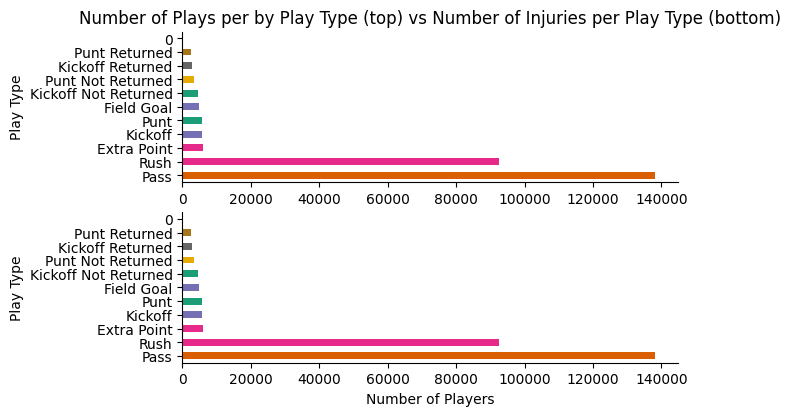

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

# Create common color map per play type
color_palette = sns.color_palette('Dark2', n_colors=len(full_merged_df['PlayType'].unique()))
color_map = dict(zip(full_merged_df['PlayType'].unique(), color_palette))


# Graph 1
# Group by 'PlayType' and sort in descending order
plt.subplot(211)  # Create a subplot at position 1, 1 (top plot)
sorted_data = full_merged_df.groupby('PlayType').size().sort_values(ascending=False)
sorted_injury_data = full_merged_df[full_merged_df["InjuryOccured"] == True].groupby('PlayType').size().sort_values(ascending=False)


# Plot the sorted data
sorted_data.plot(kind='barh', color=[color_map[pt] for pt in sorted_data.index])


# Customize the plot
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title('Number of Plays per by Play Type (top) vs Number of Injuries per Play Type (bottom)')
plt.xlabel('Number of Players')
plt.ylabel('Play Type')

# Graph 2
plt.subplot(212)  # Create a subplot at position 2, 1 (bottom plot)
# Group by 'PlayType' and sort in descending order
sorted_injury_data = full_merged_df[full_merged_df["InjuryOccured"] == True].groupby('PlayType').size().sort_values(ascending=False)

# Plot the sorted data
sorted_data.plot(kind='barh', color=[color_map[pt] for pt in sorted_data.index])

# Customize the plot
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Number of Players')
plt.ylabel('Play Type')

plt.subplots_adjust(top=.8)


plt.show()

In [ ]:
def stacked_bar_all_plays_vs_injuries(field_str,full_merged_df = full_merged_df,size=(7, 4)):
  # Group by 'field_str' column and sort in descending order of injuries
  sorted_injury_data = full_merged_df[full_merged_df["InjuryOccured"] == True].groupby(field_str).size().sort_values(ascending=False)
  sorted_data = full_merged_df.groupby(field_str).size()

  # Create a DataFrame for plotting, sorting by injuries
  df_plot = pd.DataFrame({'Injuries': sorted_injury_data, 'Plays': sorted_data})
  df_plot = df_plot.sort_values(by='Injuries', ascending=False)

  # Create the figure and axes
  fig, ax1 = plt.subplots(figsize=size)

  # Plot the plays data
  df_plot['Plays'].plot(kind='barh', ax=ax1, position=0.2, color='c', label='Plays')
  # ax1.set_ylabel('Play Type')
  ax1.set_xlabel('Number of Plays')
  ax1.tick_params(axis='x', which='both', bottom=False, top=False)

  # Plot injuries data with seperate x axis
  ax2 = ax1.twiny()
  df_plot['Injuries'].plot(kind='barh', ax=ax2, position=-0.2, color='orange', label='Injuries')
  ax2.set_xlabel('Number of Injuries')
  ax2.tick_params(axis='x', which='both', bottom=False, top=False)

  plt.title('Number of Plays & Injuries per ' + field_str)

  # Add legend (Kudos Chat GBT)
  # Combine legends
  lines, labels = ax1.get_legend_handles_labels()
  lines2, labels2 = ax2.get_legend_handles_labels()
  ax1.legend(lines + lines2, labels + labels2, loc='upper right')

  plt.show()

In [ ]:
print("Grouping of RosterPosition, PositionGroup, and Position")
full_merged_df[(full_merged_df['PositionGroup'] != 'Missing Data') & (full_merged_df['Position'] != 'Missing Data')][['RosterPosition', 'PositionGroup','Position']].drop_duplicates().groupby([ 'PositionGroup','RosterPosition','Position']).size()


Grouping of RosterPosition, PositionGroup, and Position


PositionGroup  RosterPosition     Position
DB             Cornerback         CB          1
                                  DB          1
                                  FS          1
               Safety             CB          1
                                  DB          1
                                  FS          1
                                  S           1
                                  SS          1
DL             Defensive Lineman  DE          1
                                  DT          1
                                  NT          1
                                  OLB         1
               Linebacker         DE          1
LB             Defensive Lineman  OLB         1
               Linebacker         DE          1
                                  ILB         1
                                  LB          1
                                  MLB         1
                                  OLB         1
               Safety             DB         

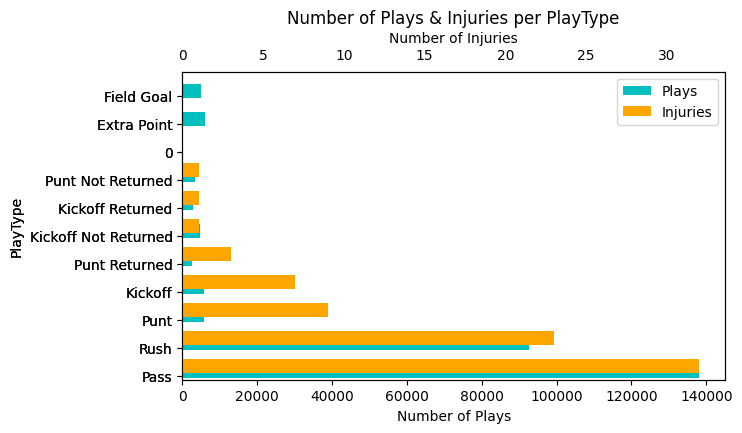

In [ ]:
stacked_bar_all_plays_vs_injuries('PlayType')

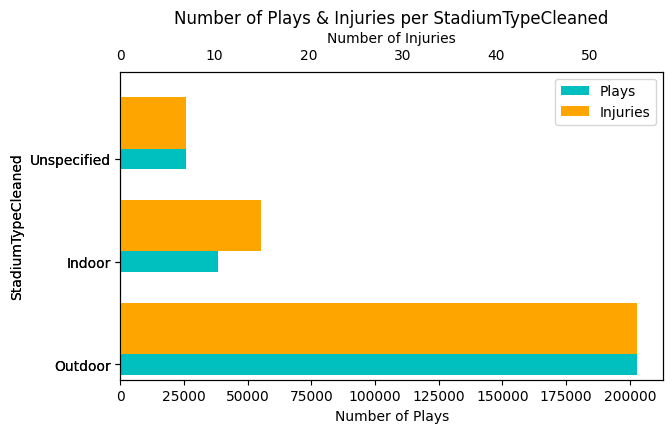

In [ ]:
stacked_bar_all_plays_vs_injuries('StadiumTypeCleaned')

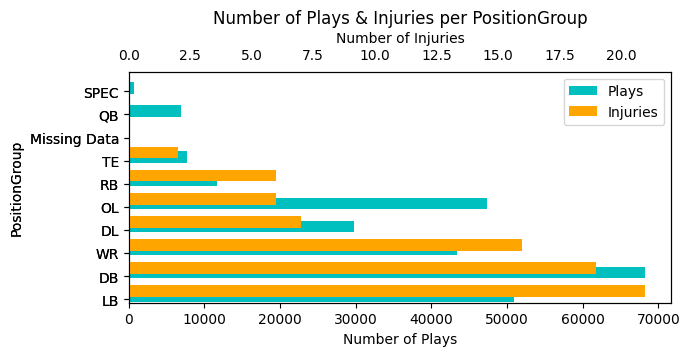

In [ ]:
stacked_bar_all_plays_vs_injuries('PositionGroup',size=(7, 3))

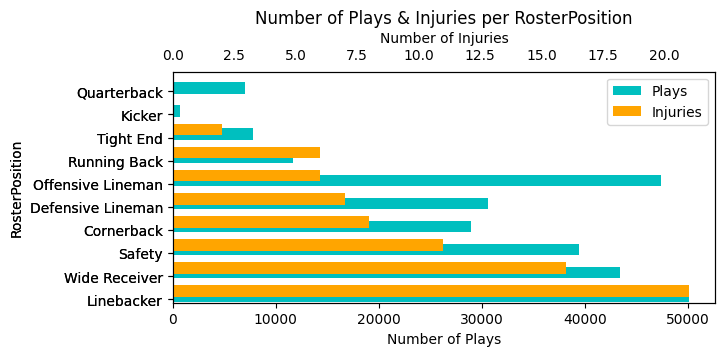

In [ ]:
stacked_bar_all_plays_vs_injuries('RosterPosition',size=(7, 3))

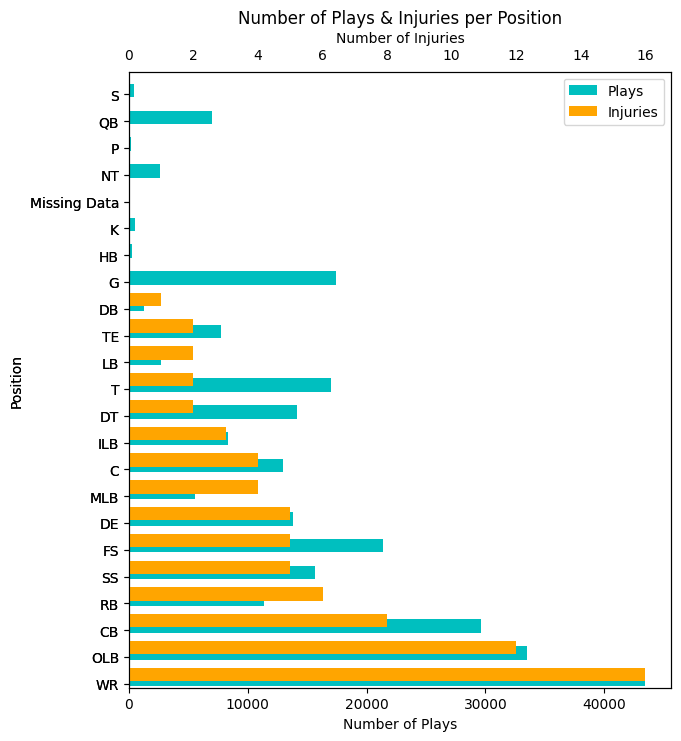

In [ ]:
stacked_bar_all_plays_vs_injuries('Position',size=(7, 8))

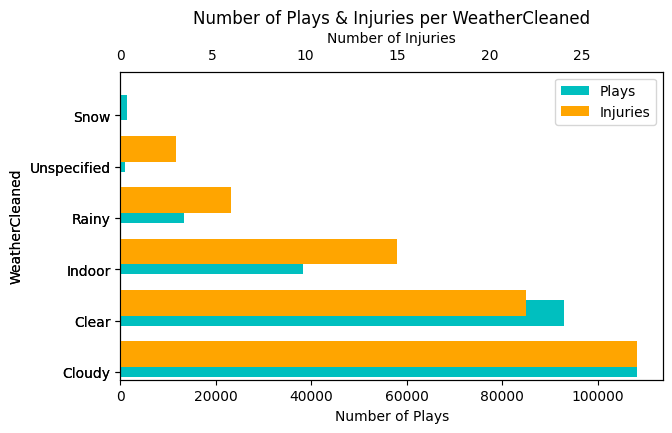

In [ ]:
stacked_bar_all_plays_vs_injuries('WeatherCleaned')

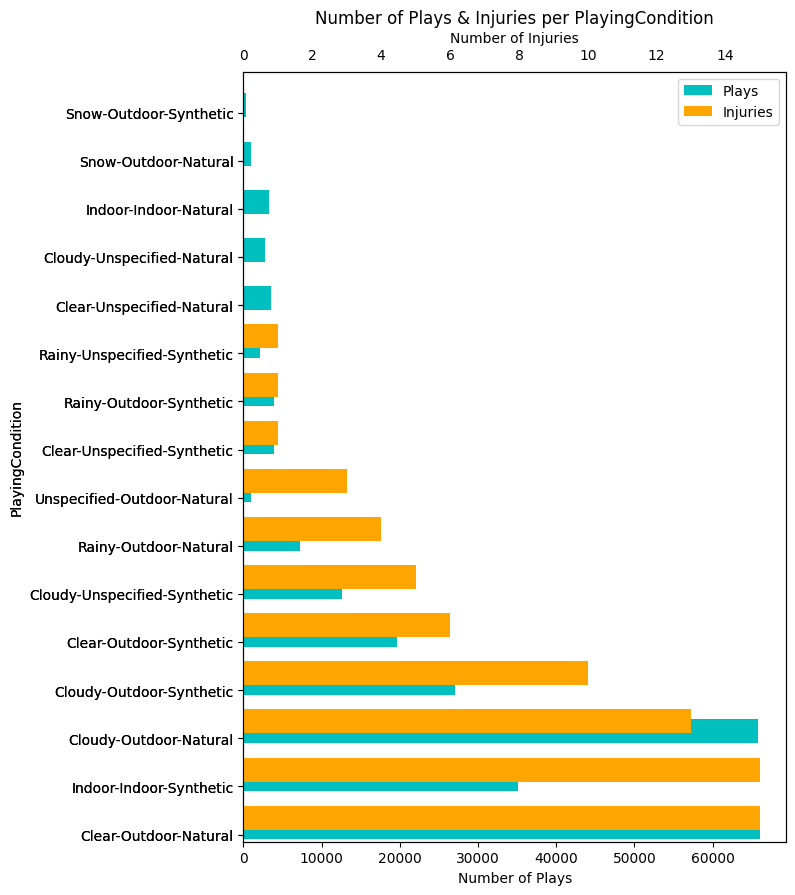

In [ ]:
full_merged_df.loc[full_merged_df['WeatherCleaned'] == "Indoor", 'StadiumTypeCleaned'] = 'Indoor'
full_merged_df['PlayingCondition'] = full_merged_df['WeatherCleaned'] + '-' + full_merged_df['StadiumTypeCleaned'] + '-' + full_merged_df['FieldType']
stacked_bar_all_plays_vs_injuries('PlayingCondition',size=(7, 10))

### **Injury Frequency**

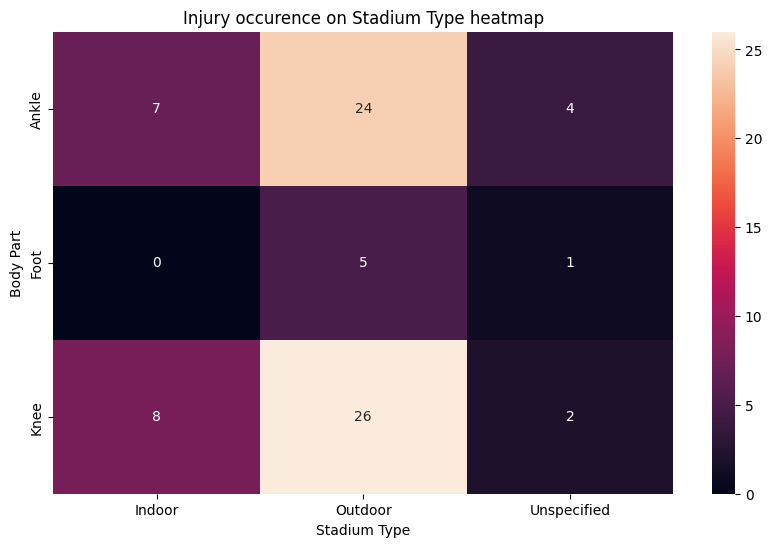

In [ ]:
# plt.subplot(211)  # Create a subplot at position 1, 1 (top plot)
grouped_df = full_merged_df.groupby(['BodyPart', 'StadiumTypeCleaned']).size().unstack(fill_value=0)

# Plot the correlation as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(grouped_df, annot=True)
plt.title('Injury occurence on Stadium Type heatmap')
plt.xlabel('Stadium Type')
plt.ylabel('Body Part')

plt.show()


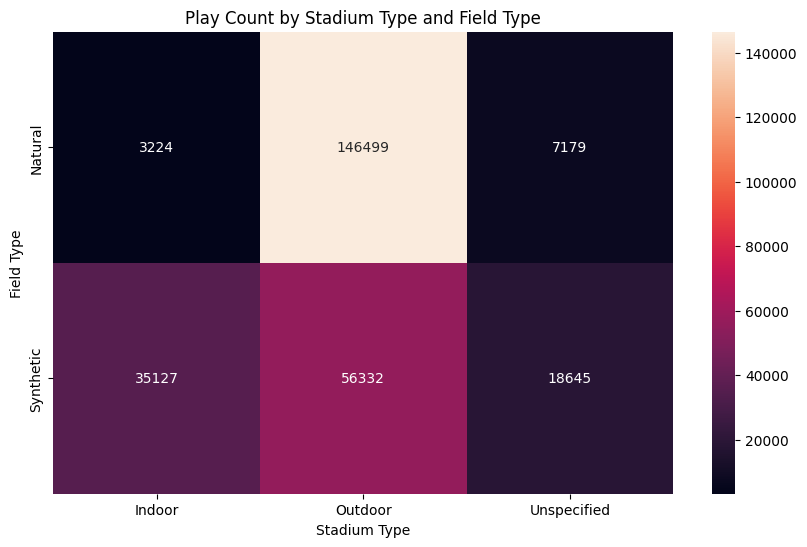

In [ ]:
# plt.subplot(211)  # Create a subplot at position 1, 1 (top plot)
# Group and format injury counts
grouped_df = full_merged_df.groupby(['FieldType', 'StadiumTypeCleaned']).size().unstack(fill_value=0)
grouped_df = grouped_df.astype(int)  # Convert values from scientific to integers

# Plot the correlation as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(grouped_df, annot=True, fmt='d')  # Use 'd' formatter for integers
plt.title('Play Count by Stadium Type and Field Type')
plt.xlabel('Stadium Type')
plt.ylabel('Field Type')

plt.show()


In [ ]:
# grouped_df = full_merged_df.groupby('StadiumTypeCleaned').size()

# # Plot the correlation as a heatmap
# plt.figure(figsize=(10, 6))
# sns.heatmap(grouped_df, annot=True)
# plt.title('Injury occurence on Stadium Type heatmap')
# plt.xlabel('Stadium Type')
# plt.ylabel('Body Part')

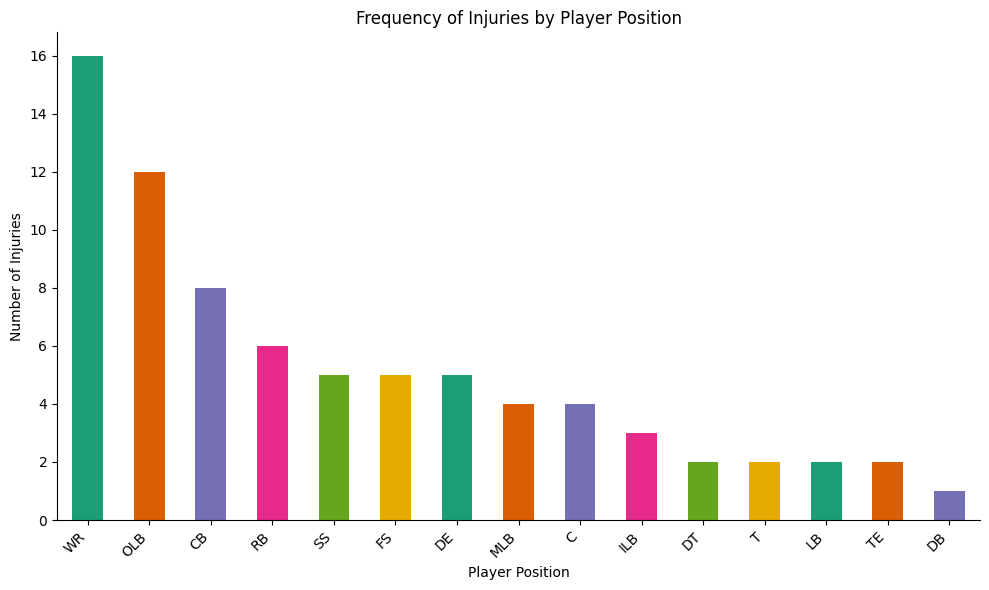

In [ ]:
# Group the merged DataFrame by 'Position' and count the number of injuries
position_injury_counts = merged_df.groupby('Position')['PlayKey'].count().sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(10, 6))
position_injury_counts.plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))
plt.title('Frequency of Injuries by Player Position')
plt.xlabel('Player Position')
plt.ylabel('Number of Injuries')
plt.xticks(rotation=45, ha='right')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


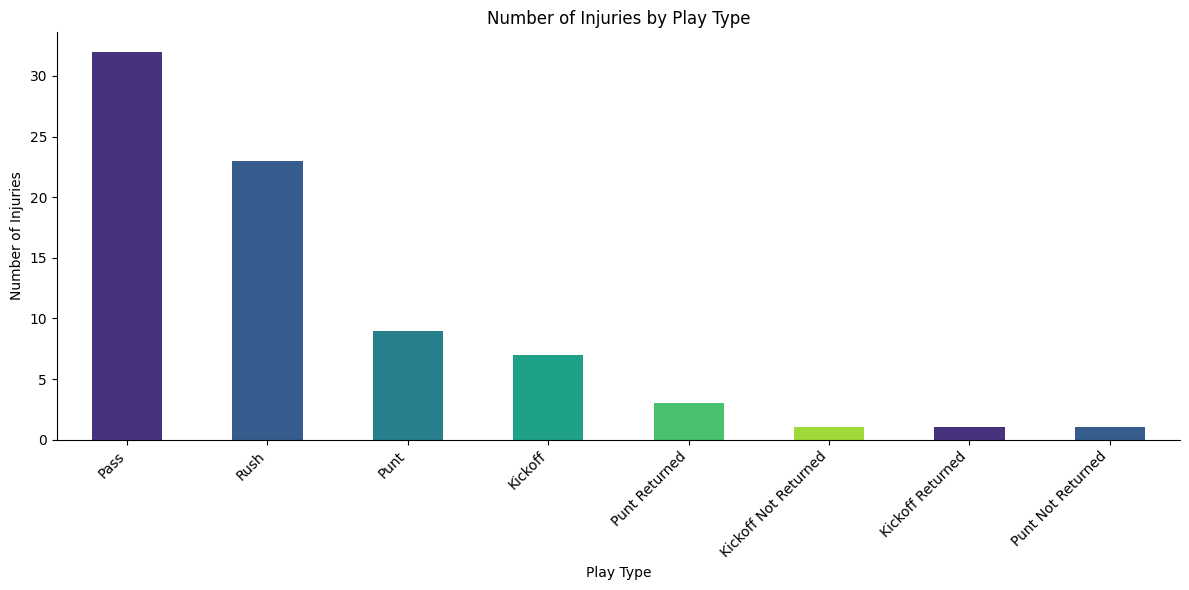

In [ ]:
# Group the merged DataFrame by 'PlayType' and count the number of injuries for each play type
play_type_injury_counts = merged_df.groupby('PlayType')['PlayKey'].count().sort_values(ascending=False)

# Create a bar chart to visualize the injury counts by play type
plt.figure(figsize=(12, 6))
play_type_injury_counts.plot(kind='bar', color=sns.color_palette("viridis"))
plt.title('Number of Injuries by Play Type')
plt.xlabel('Play Type')
plt.ylabel('Number of Injuries')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


<Figure size 1200x600 with 0 Axes>

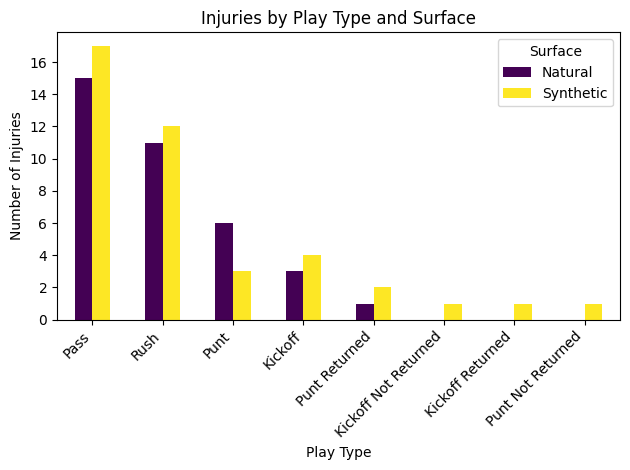

In [ ]:
# Group by 'PlayType' and 'Surface', then count 'PlayKey'
grouped_df = merged_df.groupby(['PlayType', 'Surface'])['PlayKey'].count().unstack(fill_value=0)

# Sum across surfaces to sort by total injuries per play type
total_injuries = grouped_df.sum(axis=1)
sorted_df = grouped_df.loc[total_injuries.sort_values(ascending=False).index]

# Plot the data as a grouped bar chart
plt.figure(figsize=(12, 6))
sorted_df.plot(kind='bar', colormap='viridis')
plt.title('Injuries by Play Type and Surface')
plt.xlabel('Play Type')
plt.ylabel('Number of Injuries')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Surface', loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
#Recategorize injuries according to categorization scheme
def categorize_duration(row):
  if row['DM_M42'] == 1:
    return ">= 42 days"
  elif row['DM_M28'] == 1:
    return "28-41 days"
  elif row['DM_M7'] == 1:
    return "7-27 days"
  elif row['DM_M1'] == 1:
    return "1-6 days"
  else:
    return "Unknown"  # Handle cases where none of the conditions are met

# Apply the function to create the new column
injury_df['InjuryDuration'] = injury_df.apply(categorize_duration, axis=1)

df_days_missed = injury_df.groupby(['BodyPart', 'InjuryDuration']).size().unstack(fill_value=0)

df_days_missed

InjuryDuration,1-6 days,28-41 days,7-27 days,>= 42 days
BodyPart,,,,
Ankle,16,2,13,11
Foot,0,2,0,5
Heel,0,0,1,0
Knee,11,3,21,13
Toes,2,1,4,0


In [ ]:
body_part_sums = df_days_missed.sum(axis=1)



df_days_missed_pct = df_days_missed.div(body_part_sums, axis=0)

df_days_missed_pct


InjuryDuration,1-6 days,28-41 days,7-27 days,>= 42 days
BodyPart,,,,
Ankle,0.380952,0.047619,0.309524,0.261905
Foot,0.000000,0.285714,0.000000,0.714286
Heel,0.000000,0.000000,1.000000,0.000000
Knee,0.229167,0.062500,0.437500,0.270833
Toes,0.285714,0.142857,0.571429,0.000000


### **Outcome of Injuries**

<Figure size 1200x600 with 0 Axes>

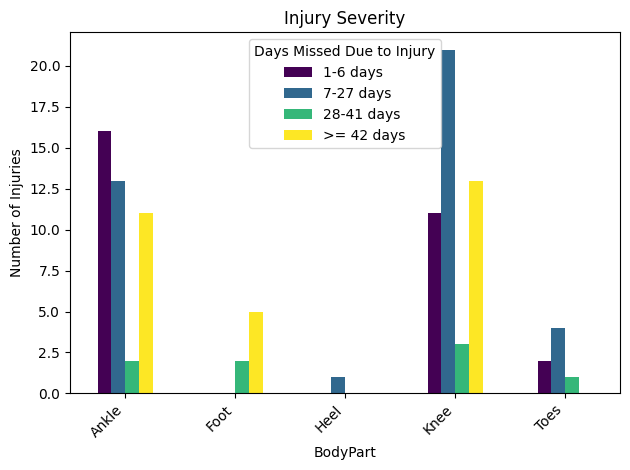

In [ ]:
# Plot the data as a grouped bar chart
plt.figure(figsize=(12, 6))

# Group by Body Part & Injury Duration
duration_by_body_part = injury_df.groupby(['BodyPart', 'InjuryDuration']).size().unstack(fill_value=0)

# Order outputs sequentially
duration_order = ["1-6 days", "7-27 days", "28-41 days", ">= 42 days"]
duration_by_body_part = duration_by_body_part[duration_order]

duration_by_body_part.plot(kind='bar', colormap='viridis')
plt.title('Injury Severity')
plt.ylabel('Number of Injuries')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Days Missed Due to Injury',loc='upper center')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

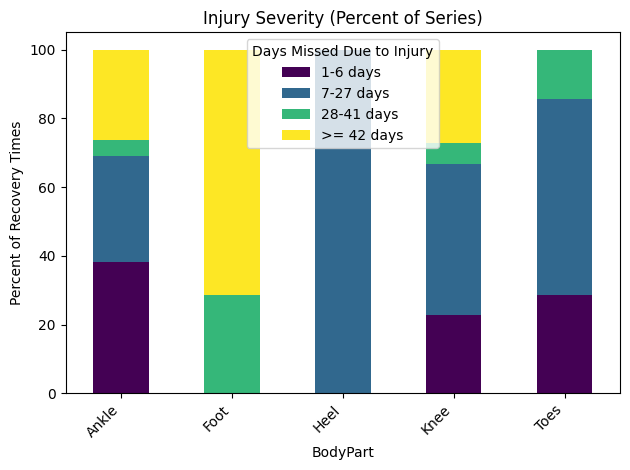

In [ ]:
plt.figure(figsize=(12, 6))

# Create a "percent of series" value for injury durations
total_injuries_by_body_part = duration_by_body_part.sum(axis=1)
proportion_by_body_part = duration_by_body_part.div(total_injuries_by_body_part, axis=0) * 100

# 4. Ensure 'InjuryDuration' is ordered correctly
duration_order = ["1-6 days", "7-27 days", "28-41 days", ">= 42 days"]
proportion_by_body_part = proportion_by_body_part[duration_order]

# 5. Plot a stacked bar chart
proportion_by_body_part.plot(kind='bar', stacked=True, colormap='viridis')

plt.title('Injury Severity (Percent of Series)')
plt.ylabel('Percent of Recovery Times')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Days Missed Due to Injury',loc='upper center')
plt.tight_layout()
plt.show()

Average expected cost per injury: 496344.9546485262


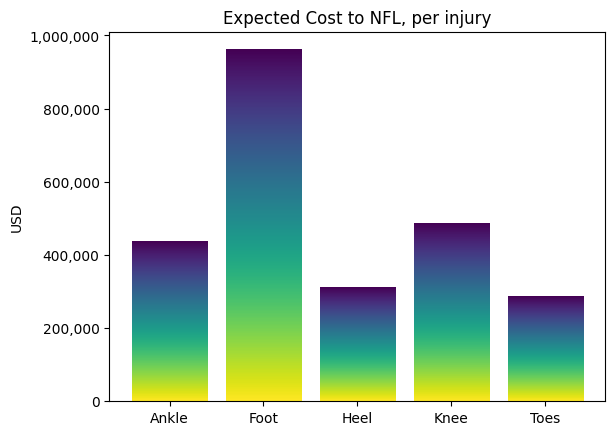

In [ ]:
#Total Cost to NFL
expected_days_missed = df_days_missed_pct.mul({'1-6 days': np.mean([1,6]),'7-27 days': np.mean([7,27]),'28-41 days': np.mean([28,41]),'>= 42 days': 60})
expected_days_missed


average_player_cost_per_day = 2300000 / (18*7)

expected_cost = expected_days_missed * average_player_cost_per_day

expected_cost_sums = expected_cost.sum(axis=1)


print("Average expected cost per injury:",expected_cost_sums.mean(axis=0))

fig, ax = plt.subplots()

bar = ax.bar(expected_cost_sums.index,expected_cost_sums)

def gradientbars(bars):
    grad = np.atleast_2d(np.linspace(0,1,256)).T
    ax = bars[0].axes
    lim = ax.get_xlim()+ax.get_ylim()
    for bar in bars:
        bar.set_zorder(1)
        bar.set_facecolor("none")
        x,y = bar.get_xy()
        w, h = bar.get_width(), bar.get_height()
        ax.imshow(grad, extent=[x,x+w,y,y+h], aspect="auto", zorder=0)
    ax.axis(lim)

gradientbars(bar)

plt.ylabel('USD')
ax.yaxis.set_major_formatter(('{x:,.0f}'))
plt.title('Expected Cost to NFL, per injury')
plt.show()

In [ ]:
#Calculate Total Cost to NFL, based only on injuries in this dataset

#Make assumptions by bin
true_days_missed = df_days_missed.mul({'1-6 days': np.mean([1,6]),'7-27 days': np.mean([7,27]),'28-41 days': np.mean([28,41]),'>= 42 days': 60})
true_days_missed

total_cost = int(true_days_missed.sum().sum()*average_player_cost_per_day)

print("The total cost to the NFL, based only on injuries in this dataset is:$",format(total_cost, ','))

The total cost to the NFL, based only on injuries in this dataset is:$ 50,755,158


###Player Track DF

In [ ]:
player_track_df.head()

,PlayKey,time,event,x,y,dir,dis,o,s
0,26624-1-1,0.0,huddle_start_offense,87.46,28.93,288.24,0.01,262.33,0.13
1,26624-1-1,0.1,NaN,87.45,28.92,283.91,0.01,261.69,0.12
2,26624-1-1,0.2,NaN,87.44,28.92,280.40,0.01,261.17,0.12
3,26624-1-1,0.3,NaN,87.44,28.92,278.79,0.01,260.66,0.10
4,26624-1-1,0.4,NaN,87.44,28.92,275.44,0.01,260.27,0.09


In [ ]:
player_track_df['event'].unique()

array(['huddle_start_offense', nan, 'huddle_break_offense', 'line_set',
       'ball_snap', 'pass_forward', 'pass_arrived',
       'pass_outcome_incomplete', 'pass_outcome_caught', 'first_contact',
       'out_of_bounds', 'man_in_motion', 'handoff', 'tackle',
       'penalty_flag', 'penalty_accepted', 'touchdown', 'shift',
       'qb_kneel', 'fumble', 'fumble_offense_recovered', 'lateral',
       'penalty_declined', 'qb_sack', 'pass_shovel',
       'pass_outcome_touchdown', 'run', 'pass_outcome_interception',
       'qb_strip_sack', 'two_point_conversion', 'pass_tipped',
       'fumble_defense_recovered', 'two_minute_warning', 'two_point_play',
       'snap_direct', 'play_action', 'qb_spike', 'pass_lateral',
       'touchback', 'timeout_tv', 'timeout', 'kickoff_play',
       'onside_kick', 'kick_received', 'safety', 'field_goal_attempt',
       'field_goal', 'punt_play', 'punt', 'punt_land', 'fair_catch',
       'punt_downed', 'punt_received', 'punt_fake', 'kickoff',
       'kickoff_la

In [ ]:
event_clean ={
    # Punt
    'punt_play':'punt', 'punt_received':'punt', 'punt_blocked':'punt', 'punt_returned':'punt', 'punt_returned_blocked':'punt', 'punt_fake':'punt', 'punt_downed':'punt', 'fair_catch': 'punt',
    'punt_land':'punt', 'punt_muffed':'punt',


    # Kickoff
    'kickoff_play':'kickoff', 'kick_received':'kickoff', 'onside_kick':'kickoff', 'kickoff_play:':'kickoff',

    #pass
    'pass_forward': 'pass', 'pass_arrived': 'pass', 'pass_outcome_caught': 'pass', 'pass_outcome_incomplete': 'pass', 'pass_incomplete': 'pass',

    #Huddle
    'huddle_break_offense':'huddle', 'huddle_start_defense':'huddle',

    #Fumble
    'fumble_defense_recovered':'fumble', 'fumble_offense_recovered':'fumble',

    # Field Goal
    'field_goal_play':'field_goal',

    #Penalty
    'penalty_flag':'penalty', 'penalty_accepted':'penalty', 'penalty_declined':'penalty'
      }

In [ ]:
player_track_df['event'].replace(event_clean, inplace= True)

In [ ]:
# Merge the two DataFrames on the common column 'PlayKey'
injury_track_df = pd.merge(injury_df, player_track_df, on='PlayKey')

background = Image.open('/content/drive/MyDrive/NFL_Field.png')
background = background.resize((1000,533))
background = background.transpose(PIL.Image.FLIP_TOP_BOTTOM)
figsize=(24,10)
fig = plt.figure(figsize=figsize)



<Figure size 2400x1000 with 0 Axes>

### **Injuries on the Field**

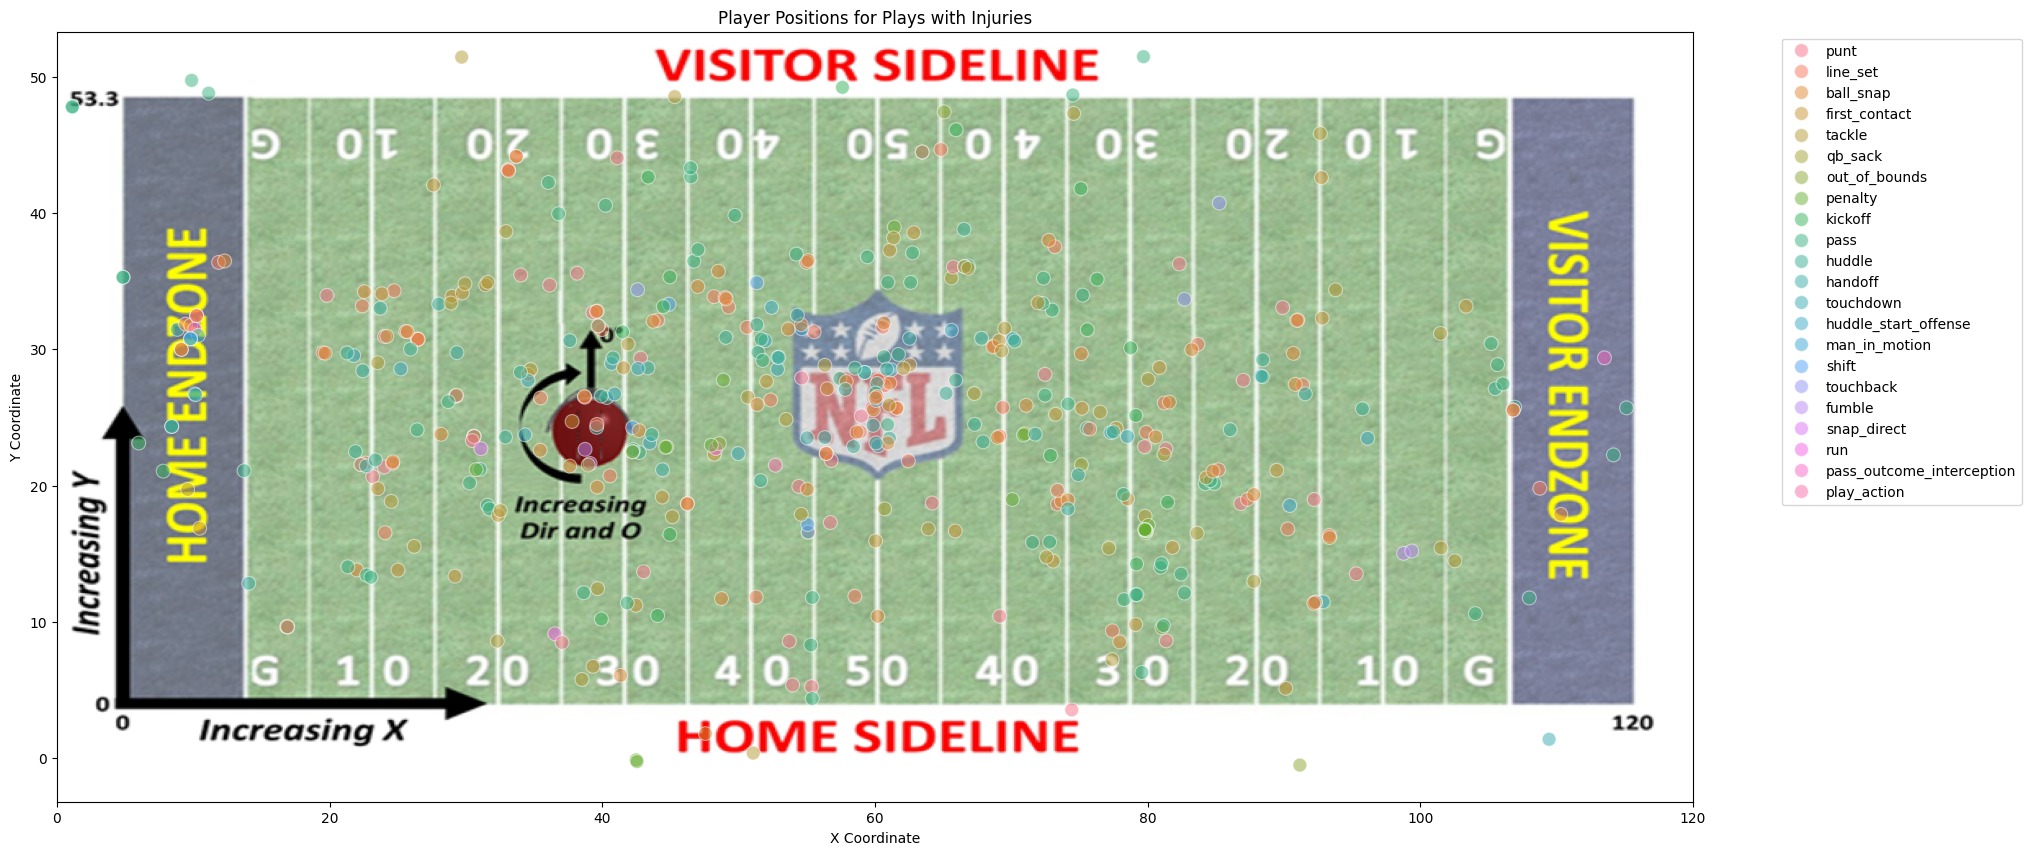

In [ ]:
# Create a scatter plot of player positions for plays with injuries
fig = plt.figure(figsize=figsize)
plt.imshow(np.array(background).transpose(0,1,2), origin='lower', extent=[0, 120, 0, 53.3])  # Set alpha for transparency
sns.scatterplot(x='x', y='y', data=injury_track_df, hue='event', s=100, alpha=0.5)
plt.title('Player Positions for Plays with Injuries')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


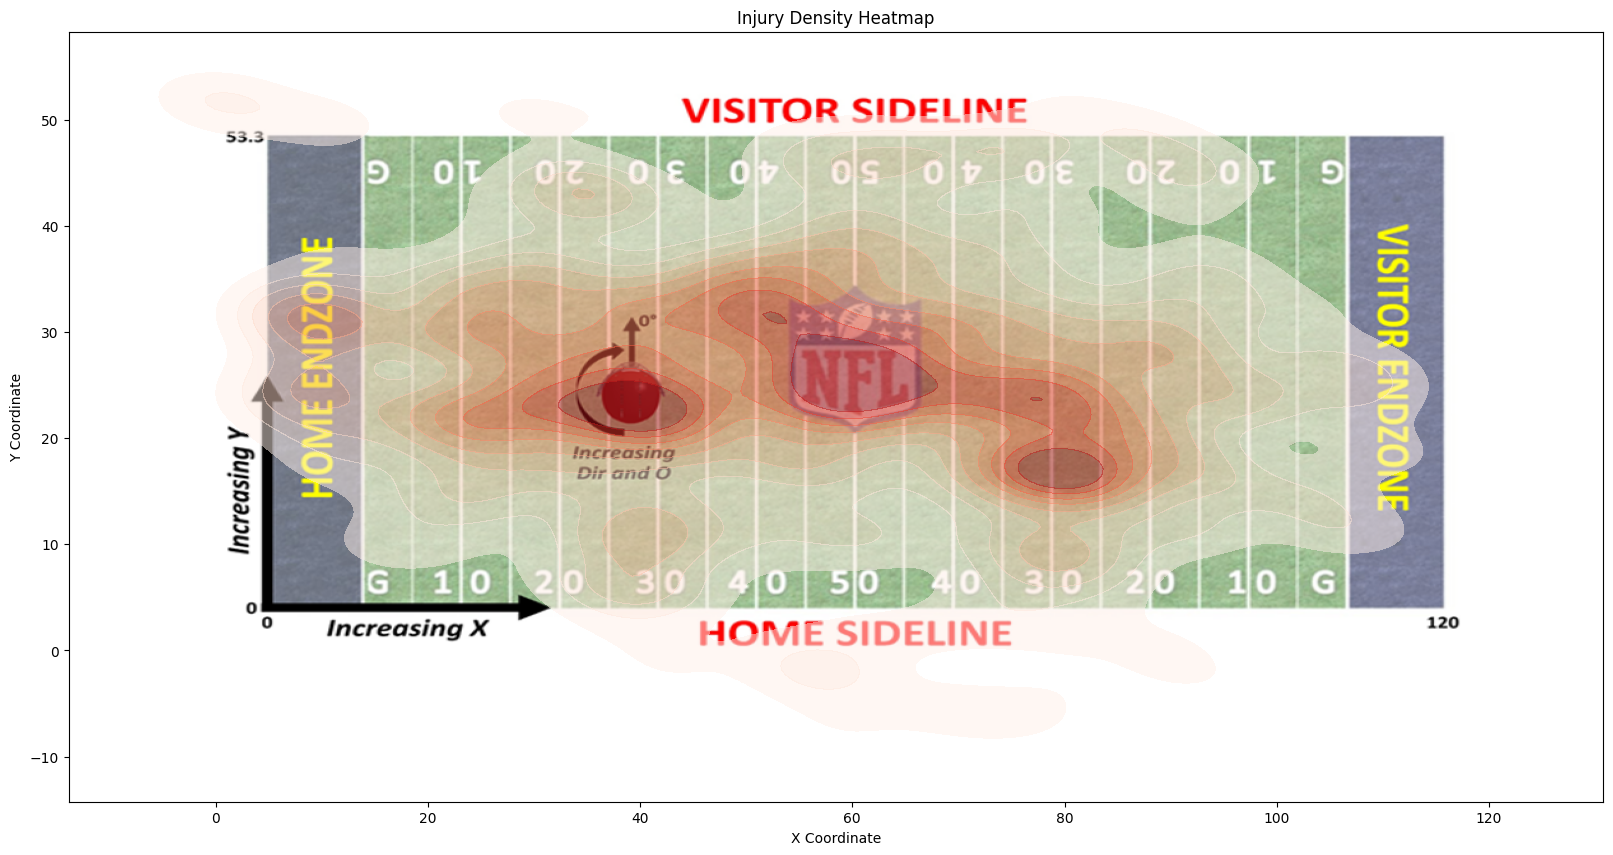

In [ ]:
# Create a heatmap of injury density
fig = plt.figure(figsize=figsize)
plt.imshow(np.array(background).transpose(0,1,2), origin='lower', extent=[0, 120, 0, 53.3])  # Set alpha for transparency
sns.kdeplot(x='x', y='y', data=injury_track_df, fill=True, cmap='Reds',alpha=0.5)
plt.title('Injury Density Heatmap')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()